# Replication of Nesbitt, Cifelli & Rutledge (2006)
### *Storm Morphology and Rainfall Characteristics of TRMM Precipitation Features* — *Mon. Wea. Rev.*, **134**, 2702–2721, [doi:10.1175/MWR3200.1](https://doi.org/10.1175/MWR3200.1)

Reproduces the paper's central results on the **PF superdatabase** (`pf_catalog.duckdb`),
pushing every aggregation into DuckDB (no full-table pull). The headline result —
**a small fraction of precipitation features (MCSs) produces most of the rainfall** —
falls straight out of the feature table.

**Sections**
1. PF population & rainfall contribution by morphological class (their Tables/Fig. 7–8).
2. Cumulative rainfall contribution vs. feature **size** (their Fig. 9).
3. Rainfall vs. **convective intensity** (max 40-dBZ height) and **ice scattering** (min 85-GHz PCT).
4. **Convective/stratiform** rain partition by region & latitude.
5. **Geographic** distribution of rainfall and the MCS rain fraction.

**Faithfulness notes / differences from the 2006 paper**
- **Record:** this DB is TRMM PR **1997-12 → 2014-10-07** (PR shutoff), vs. the paper's
  Aug 1998–Jul 2000. Longer sample, same instrument (GPM-reprocessed 2A `GPM_2APR`, V07).
- **MCS definition:** the DB flags `feature_class='MCS'` by **contiguous radar precip area ≥ 2000 km²**
  (`MCS_AREA_KM2`). The paper's MCS is the **85-GHz PCT** criterion (contiguous ≥ 2000 km² with
  PCT ≤ 250 K, min PCT ≤ 225 K). They largely coincide; §3 shows the PCT/ice axis directly.
- **Feature definition:** per-instrument noise floor (TRMM **16 dBZ**), 1-pixel minimum — more
  permissive than the paper's. Convective/stratiform from the 2A rain-type flag (2=conv, 1=strat).

Set `MISSION = "GPM"` in the next cell to run the same analysis on the GPM Ku record.

In [1]:
import warnings
import numpy as np, pandas as pd
import duckdb
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
try:
    import cartopy.crs as ccrs, cartopy.feature as cfeature
    HAVE_CARTOPY = True
except Exception:
    HAVE_CARTOPY = False

MISSION = "TRMM"                       # faithful to the paper; set "GPM" for the Ku record
CATALOG = "/data/scratch/a/snesbitt/pf_db/pf_catalog.duckdb"
con = duckdb.connect(CATALOG, read_only=True); con.execute("PRAGMA threads=16")

def q(sql, *p):                        # tiny helper: SQL aggregation -> small DataFrame
    return con.execute(sql, [MISSION, *p]).df()

n, vr = con.execute(
    "SELECT count(*), sum(volrain_total) FROM features WHERE mission=?", [MISSION]).fetchone()
print(f"{MISSION}: {n:,} precipitation features, "
      f"total near-surface volumetric rain index = {vr:,.0f} (mm hr^-1 * km^2)")

TRMM: 90,349,093 precipitation features, total near-surface volumetric rain index = 83,426,991,668 (mm hr^-1 * km^2)


## 1 — PF population and rainfall contribution by class
The paper's central table: each morphological class as a **fraction of feature count** vs.
**fraction of total rainfall**. The disparity (MCSs rare but rain-dominant) is the key result.

TRMM — PF population and rainfall by class:

                % of features % of rainfall mean area (km²) mean min-PCT (K) conv rain %
class                                                                                   
MCS                     1.70%        74.20%          11,188              212       45.8%
sub_MCS_conv           85.47%        24.18%             111              281       74.5%
stratiform_only        12.69%         1.62%             117              272        0.0%
weak                    0.14%         0.00%              21              276        0.0%


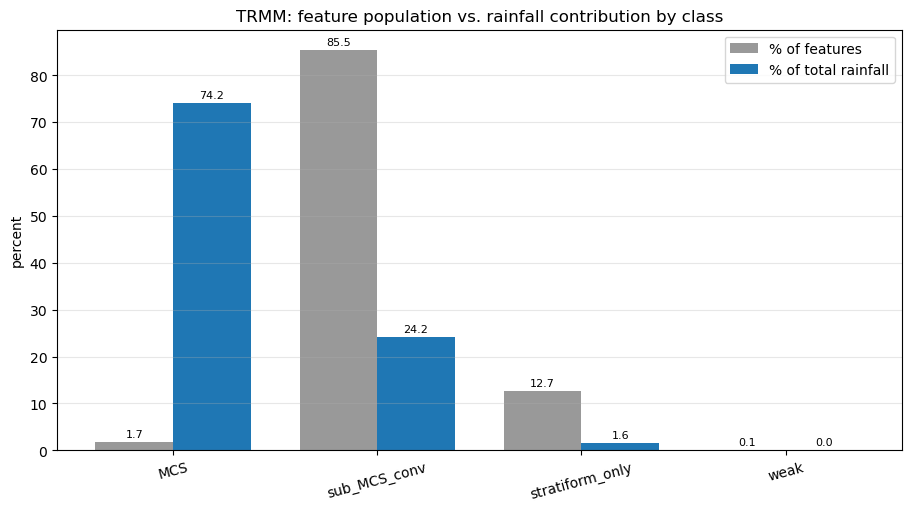

In [2]:
ORDER = ["MCS", "sub_MCS_conv", "stratiform_only", "weak"]
tab = q("""
    SELECT feature_class AS class,
           count(*)                         AS n_feat,
           100.0*count(*)/sum(count(*))OVER()              AS pct_feat,
           sum(volrain_total)               AS rain,
           100.0*sum(volrain_total)/sum(sum(volrain_total))OVER() AS pct_rain,
           avg(area_km2)                    AS mean_area_km2,
           avg(min_pct_85_89)               AS mean_min_pct,
           100.0*sum(volrain_conv)/sum(volrain_total)      AS conv_rain_pct
    FROM features WHERE mission=?
    GROUP BY 1
""").set_index("class").reindex(ORDER)

show = pd.DataFrame({
    "% of features":  tab.pct_feat.map("{:.2f}%".format),
    "% of rainfall":  tab.pct_rain.map("{:.2f}%".format),
    "mean area (km²)": tab.mean_area_km2.map("{:,.0f}".format),
    "mean min-PCT (K)": tab.mean_min_pct.map("{:.0f}".format),
    "conv rain %":    tab.conv_rain_pct.map("{:.1f}%".format),
})
print(f"{MISSION} — PF population and rainfall by class:\n")
print(show.to_string())

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
x = np.arange(len(ORDER)); w = 0.38
ax.bar(x - w/2, tab.pct_feat, w, label="% of features", color="0.6")
ax.bar(x + w/2, tab.pct_rain, w, label="% of total rainfall", color="tab:blue")
for i, (pf, pr) in enumerate(zip(tab.pct_feat, tab.pct_rain)):
    ax.text(i - w/2, pf + 1, f"{pf:.1f}", ha="center", fontsize=8)
    ax.text(i + w/2, pr + 1, f"{pr:.1f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=15)
ax.set_ylabel("percent"); ax.set_title(f"{MISSION}: feature population vs. rainfall contribution by class")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.show()

## 2 — Cumulative rainfall contribution vs. feature size
Rainfall is binned by feature area (log-spaced). The cumulative curve shows the
**fraction of total rain from features ≤ a given size** — the paper's result that
the largest features dominate the accumulation. Split land vs. ocean.

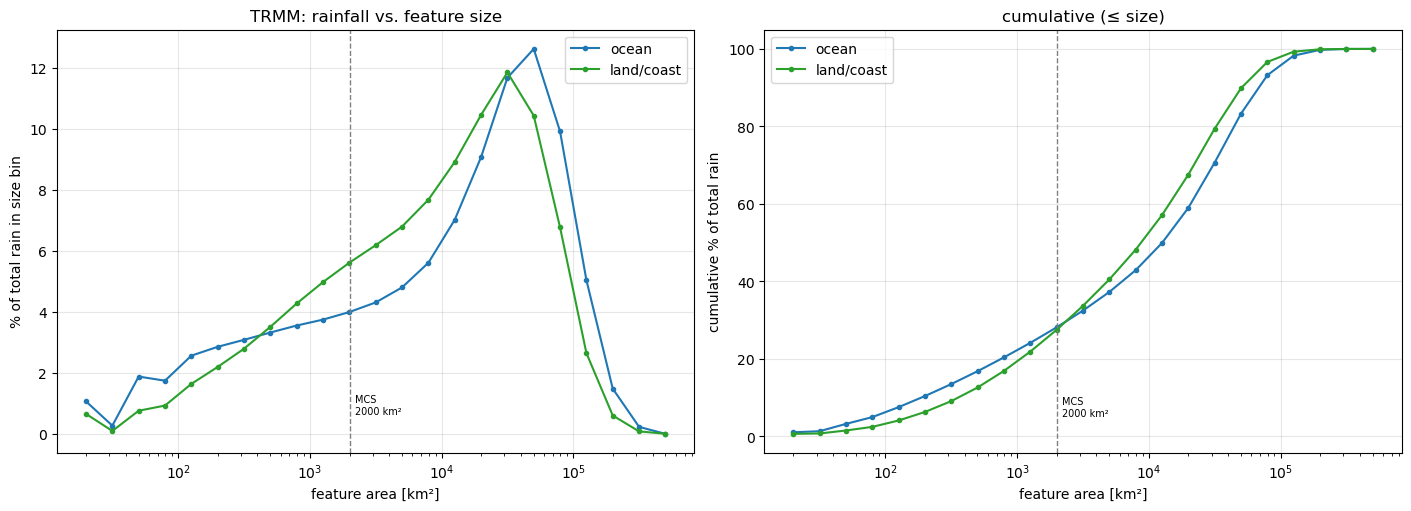

In [3]:
DEX = 0.2   # log10(area) bin width
g = q(f"""
    SELECT CASE WHEN frac_ocean >= 0.5 THEN 'ocean' ELSE 'land/coast' END AS surf,
           CAST(floor(log10(area_km2)/{DEX}) AS INT) AS b,
           sum(volrain_total) AS rain
    FROM features WHERE mission=? AND area_km2 > 0
    GROUP BY 1, 2
""")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for surf, c in [("ocean", "tab:blue"), ("land/coast", "tab:green")]:
    s = g[g.surf == surf].sort_values("b")
    area = 10.0 ** ((s.b + 0.5) * DEX)
    frac = s.rain.to_numpy() / g[g.surf == surf].rain.sum()
    a1.plot(area, 100*frac, "-o", ms=3, color=c, label=surf)
    a2.plot(area, 100*np.cumsum(frac), "-o", ms=3, color=c, label=surf)
for a in (a1, a2):
    a.set_xscale("log"); a.set_xlabel("feature area [km²]"); a.grid(alpha=0.3); a.legend()
    a.axvline(2000, color="0.5", ls="--", lw=1); a.text(2200, a.get_ylim()[1]*0.05, "MCS\n2000 km²", fontsize=7)
a1.set_ylabel("% of total rain in size bin"); a1.set_title(f"{MISSION}: rainfall vs. feature size")
a2.set_ylabel("cumulative % of total rain"); a2.set_title("cumulative (≤ size)")
plt.show()

## 3 — Rainfall vs. convective intensity and ice scattering
Two physical axes the paper emphasizes: maximum **40-dBZ echo-top height** (convective
vigour / mixed-phase depth) and minimum **85-GHz PCT** (column ice → deep convection).
Bars show the fraction of total rainfall contributed at each intensity.

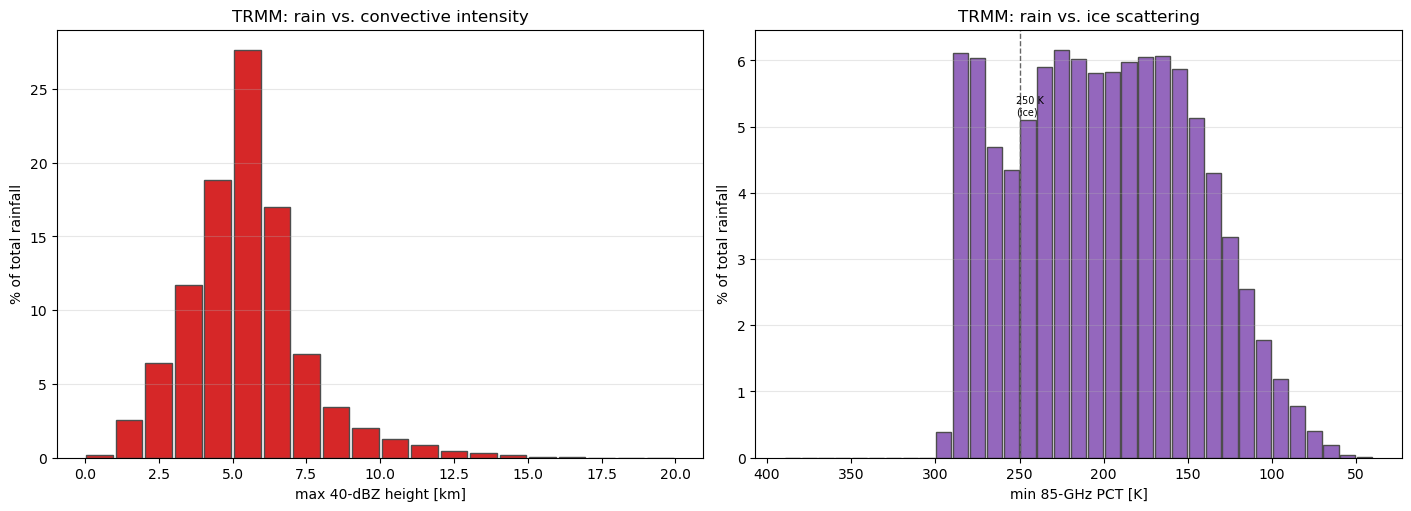

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# (a) by max 40-dBZ height (1-km bins). ht=0 => no 40-dBZ echo detected.
h = q("""
    SELECT CAST(floor(max_ht_40dbz/1000.0) AS INT) AS b, sum(volrain_total) AS rain
    FROM features WHERE mission=? AND max_ht_40dbz IS NOT NULL
    GROUP BY 1 ORDER BY 1
""")
tot = h.rain.sum()
a1.bar(h.b + 0.5, 100*h.rain/tot, width=0.9, color="tab:red", edgecolor="0.3")
a1.set_xlabel("max 40-dBZ height [km]"); a1.set_ylabel("% of total rainfall")
a1.set_title(f"{MISSION}: rain vs. convective intensity"); a1.grid(axis="y", alpha=0.3)

# (b) by min 85-GHz PCT (10-K bins); colder PCT = more ice = deeper convection.
p = q("""
    SELECT CAST(floor(min_pct_85_89/10.0) AS INT)*10 AS pct_bin, sum(volrain_total) AS rain
    FROM features WHERE mission=? AND min_pct_85_89 IS NOT NULL AND isfinite(min_pct_85_89)
    GROUP BY 1 ORDER BY 1
""")
a2.bar(p.pct_bin + 5, 100*p.rain/p.rain.sum(), width=9, color="tab:purple", edgecolor="0.3")
a2.axvline(250, color="0.4", ls="--", lw=1); a2.text(252, a2.get_ylim()[1]*0.8, "250 K\n(ice)", fontsize=7)
a2.set_xlabel("min 85-GHz PCT [K]"); a2.set_ylabel("% of total rainfall")
a2.set_title(f"{MISSION}: rain vs. ice scattering"); a2.grid(axis="y", alpha=0.3); a2.invert_xaxis()
plt.show()

## 4 — Convective / stratiform rainfall partition
From the 2A rain-type flag: convective vs. stratiform volumetric-rain shares, by surface
and by latitude. The paper's land/ocean contrast in convective fraction is reproduced.

TRMM — convective/stratiform rain share by surface:

       conv_pct  strat_pct
surf                      
ocean      51.6       48.4
land       53.2       46.8
coast      81.9       17.9


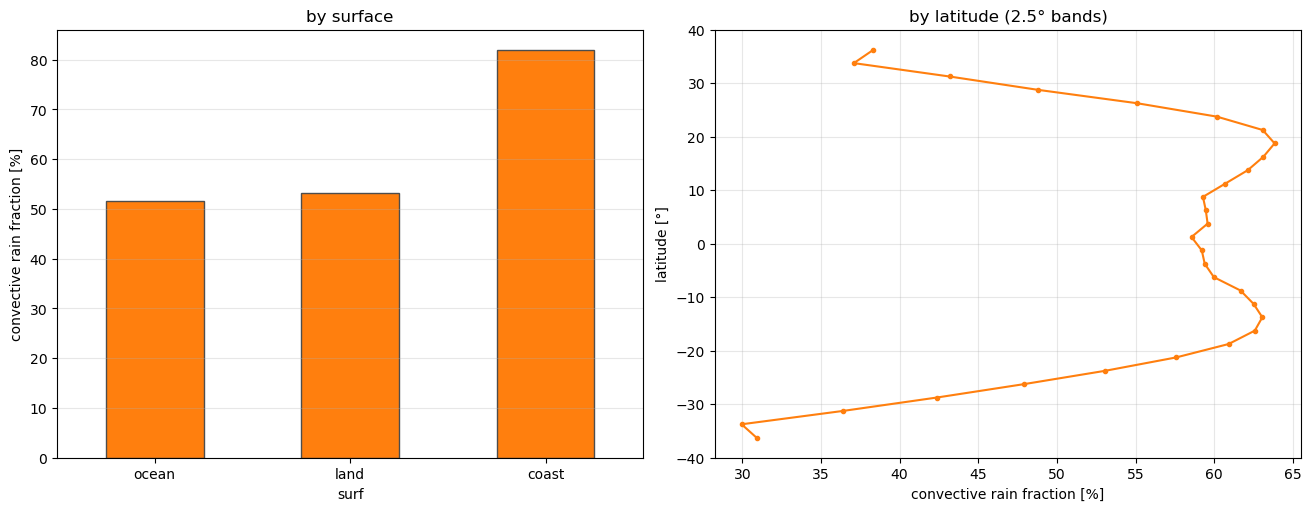

In [5]:
byreg = q("""
    SELECT CASE WHEN frac_ocean>=0.5 THEN 'ocean' WHEN frac_land>=0.5 THEN 'land' ELSE 'coast' END AS surf,
           100.0*sum(volrain_conv)/sum(volrain_total)  AS conv_pct,
           100.0*sum(volrain_strat)/sum(volrain_total) AS strat_pct
    FROM features WHERE mission=? GROUP BY 1
""").set_index("surf").reindex(["ocean","land","coast"])
print(f"{MISSION} — convective/stratiform rain share by surface:\n")
print(byreg.round(1).to_string())

lat = q("""
    SELECT CAST(floor(centroid_lat/2.5) AS INT)*2.5 + 1.25 AS lat,
           100.0*sum(volrain_conv)/sum(volrain_total) AS conv_pct
    FROM features WHERE mission=? GROUP BY 1 ORDER BY 1
""")
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
byreg["conv_pct"].plot.bar(ax=a1, color="tab:orange", edgecolor="0.3")
a1.set_ylabel("convective rain fraction [%]"); a1.set_title("by surface"); a1.grid(axis="y", alpha=0.3)
a1.set_xticklabels(byreg.index, rotation=0)
a2.plot(lat.conv_pct, lat.lat, "-o", ms=3, color="tab:orange")
a2.set_xlabel("convective rain fraction [%]"); a2.set_ylabel("latitude [°]")
a2.set_title("by latitude (2.5° bands)"); a2.grid(alpha=0.3); a2.set_ylim(-40, 40)
plt.show()

## 5 — Geographic distribution of rainfall and MCS dominance
Total feature rainfall gridded to 2.5°, and the **fraction of rainfall from MCSs** —
the paper's map of where organized convection dominates the rain (continents, ITCZ,
warm-pool, vs. shallow maritime rain).

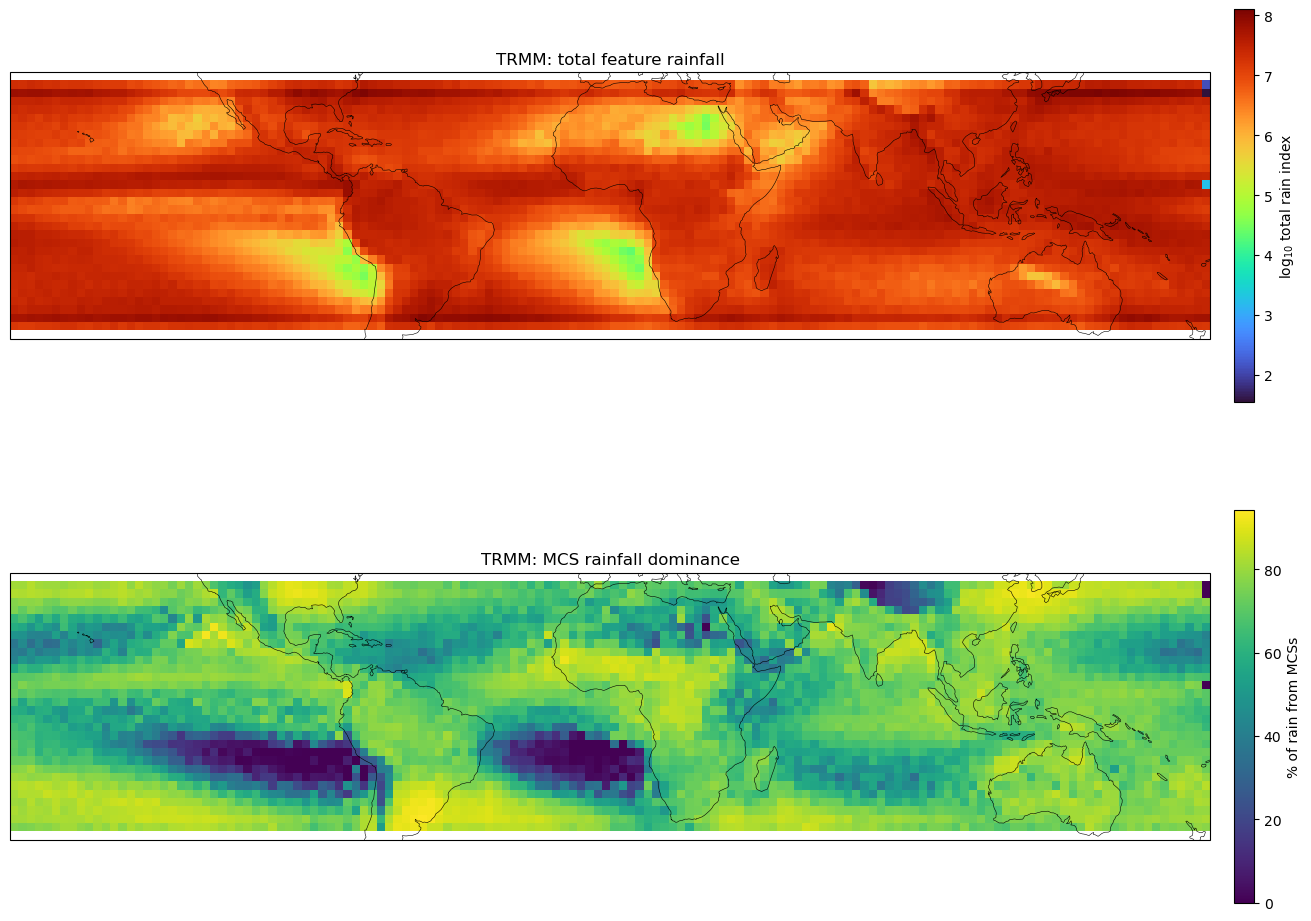

In [6]:
D = 2.5
gm = q(f"""
    SELECT CAST(floor((centroid_lon+180)/{D}) AS INT) AS ix,
           CAST(floor((centroid_lat+90)/{D})  AS INT) AS iy,
           sum(volrain_total)                                   AS rain_all,
           sum(volrain_total) FILTER (WHERE feature_class='MCS') AS rain_mcs
    FROM features WHERE mission=?
      AND centroid_lon>=-180 AND centroid_lon<180 AND centroid_lat>=-90 AND centroid_lat<90
    GROUP BY 1,2
""")
nlon, nlat = int(360/D), int(180/D)
lons = -180 + (np.arange(nlon)+0.5)*D; lats = -90 + (np.arange(nlat)+0.5)*D
RAIN = np.full((nlat, nlon), np.nan); MCSF = np.full((nlat, nlon), np.nan)
iy = np.clip(gm.iy.to_numpy(), 0, nlat-1); ix = np.clip(gm.ix.to_numpy(), 0, nlon-1)
RAIN[iy, ix] = gm.rain_all.to_numpy()
MCSF[iy, ix] = 100.0 * gm.rain_mcs.fillna(0).to_numpy() / gm.rain_all.to_numpy()

proj = dict(projection=ccrs.PlateCarree()) if HAVE_CARTOPY else {}
fig, axes = plt.subplots(2, 1, figsize=(13, 10), subplot_kw=proj, constrained_layout=True)
panels = [(np.log10(np.ma.masked_invalid(RAIN)), "turbo", "log$_{10}$ total rain index", "total feature rainfall"),
          (np.ma.masked_invalid(MCSF), "viridis", "% of rain from MCSs", "MCS rainfall dominance")]
for ax, (Z, cmap, clabel, title) in zip(axes, panels):
    pcm = ax.pcolormesh(np.r_[lons-D/2, lons[-1]+D/2], np.r_[lats-D/2, lats[-1]+D/2], Z,
                        cmap=cmap, shading="auto",
                        transform=ccrs.PlateCarree() if HAVE_CARTOPY else None)
    if HAVE_CARTOPY:
        ax.coastlines(linewidth=0.4); ax.set_ylim(-40, 40)
    fig.colorbar(pcm, ax=ax, shrink=0.8, pad=0.02, label=clabel)
    ax.set_title(f"{MISSION}: {title}")
plt.show()

## 6 — Diurnal cycle by surface and feature type
Local solar time = UTC + longitude/15. Rainfall normalized to its daily mean shows the
canonical contrast the TRMM-PF literature established: **continental** convection peaks
in the **afternoon**, **oceanic** rain is weaker and peaks in the **early morning**;
**MCSs** lag the smaller afternoon convection (they mature and rain into the
evening/overnight).

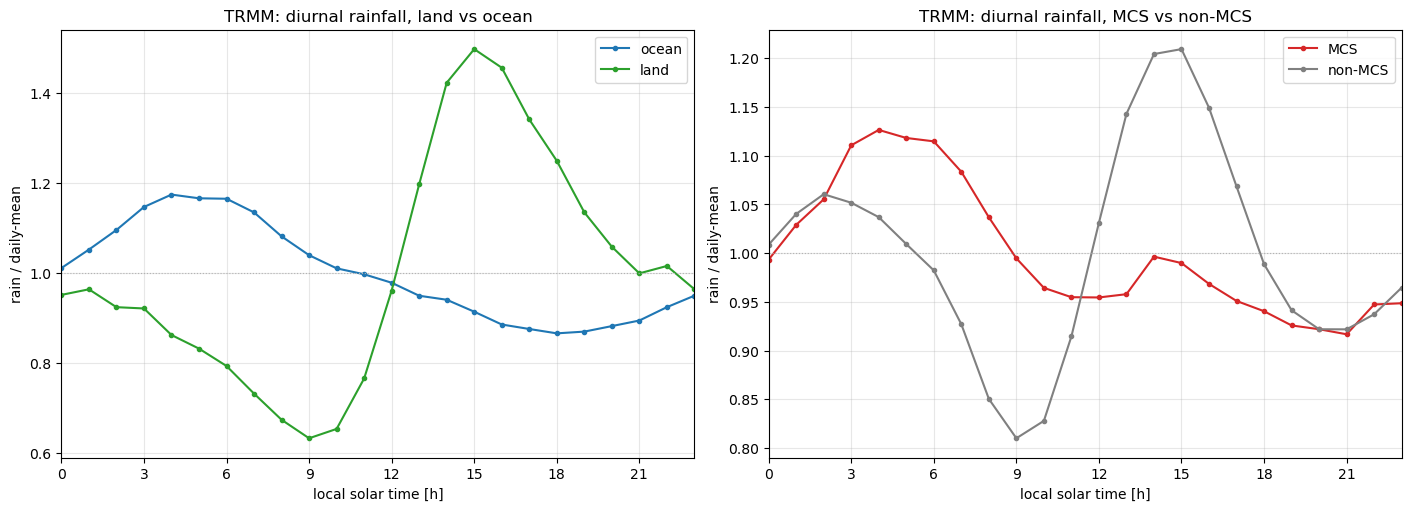

In [7]:
dd = q("""
    SELECT CASE WHEN frac_ocean>=0.5 THEN 'ocean' ELSE 'land' END AS surf,
           is_mcs,
           ((CAST(floor(extract(hour FROM time) + extract(minute FROM time)/60.0
                  + centroid_lon/15.0) AS INT) % 24) + 24) % 24 AS lst,
           sum(volrain_total) AS rain
    FROM features WHERE mission=? AND time IS NOT NULL
    GROUP BY 1,2,3
""")

def diurnal(mask):
    s = dd[mask].groupby("lst").rain.sum().reindex(range(24), fill_value=0.0)
    return s / s.mean()            # normalized to daily mean (1.0 = average hour)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for surf, c in [("ocean", "tab:blue"), ("land", "tab:green")]:
    a1.plot(range(24), diurnal(dd.surf == surf), "-o", ms=3, color=c, label=surf)
a1.set_title(f"{MISSION}: diurnal rainfall, land vs ocean")
for lab, mask, c in [("MCS", dd.is_mcs, "tab:red"), ("non-MCS", ~dd.is_mcs, "0.5")]:
    a2.plot(range(24), diurnal(mask), "-o", ms=3, color=c, label=lab)
a2.set_title(f"{MISSION}: diurnal rainfall, MCS vs non-MCS")
for a in (a1, a2):
    a.axhline(1.0, color="0.7", lw=0.8, ls=":"); a.set_xlim(0, 23); a.set_xticks(range(0, 24, 3))
    a.set_xlabel("local solar time [h]"); a.set_ylabel("rain / daily-mean"); a.legend(); a.grid(alpha=0.3)
plt.show()

## 7 — Joint distribution of feature size and conditional rain rate
2-D histogram of feature **area** (log) vs **conditional mean rain rate**
(`volrain_total / area` = area-mean rate over the raining feature). Left panel is the
**feature-count** density (most features are small and light); right panel weights each
bin by its **rainfall contribution**, showing the size–intensity regime that actually
produces the rain — large, moderate-intensity (organized) features, per the paper.

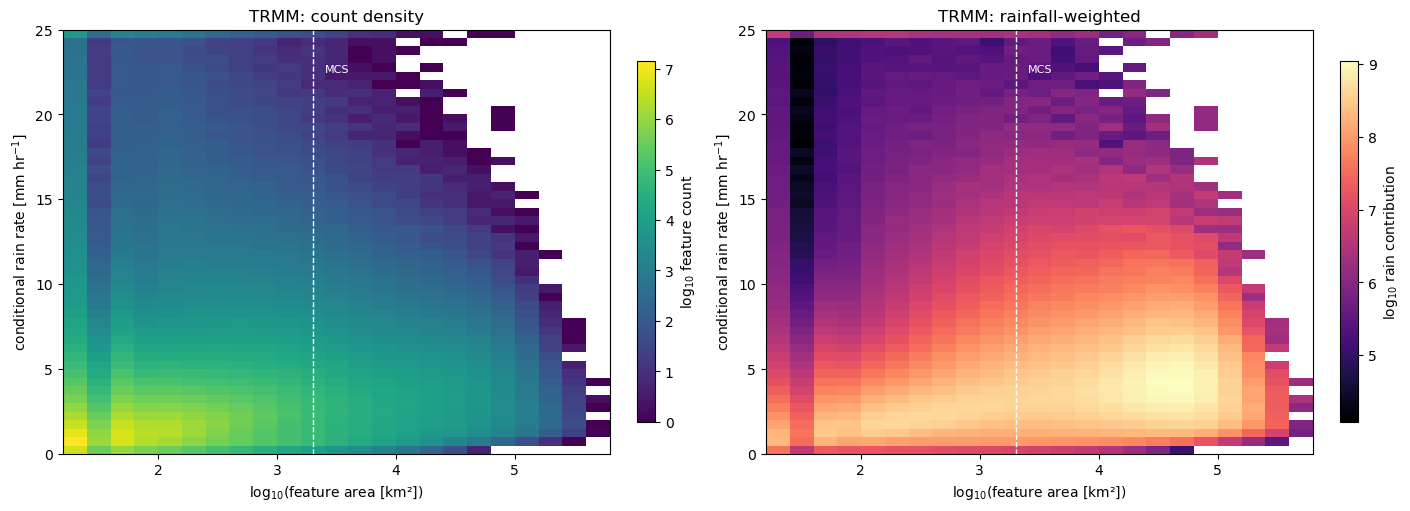

In [8]:
AB, RB, RMAX = 0.2, 0.5, 25.0           # log10-area dex, rate bin (mm/hr), rate cap
h2 = q(f"""
    SELECT CAST(floor(log10(area_km2)/{AB}) AS INT) AS ab,
           CAST(floor(LEAST(volrain_total/area_km2, {RMAX})/{RB}) AS INT) AS rb,
           count(*) AS n, sum(volrain_total) AS rain
    FROM features WHERE mission=? AND area_km2>0 AND volrain_total>0
    GROUP BY 1,2
""")
ab0, ab1 = int(h2.ab.min()), int(h2.ab.max())
nrb = int(RMAX/RB)
nab = ab1 - ab0 + 1
N = np.zeros((nrb, nab)); R = np.zeros((nrb, nab))
ii = np.clip(h2.rb.to_numpy(), 0, nrb-1); jj = h2.ab.to_numpy() - ab0
np.add.at(N, (ii, jj), h2.n.to_numpy()); np.add.at(R, (ii, jj), h2.rain.to_numpy())
extent = [ab0*AB, (ab1+1)*AB, 0, RMAX]   # x=log10(area km2), y=rate mm/hr

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, (Z, cmap, lab, title) in zip(axes, [
        (np.ma.masked_equal(N, 0), "viridis", "log$_{10}$ feature count", "count density"),
        (np.ma.masked_equal(R, 0), "magma",   "log$_{10}$ rain contribution", "rainfall-weighted")]):
    im = ax.imshow(np.log10(Z), origin="lower", aspect="auto", extent=extent, cmap=cmap)
    ax.axvline(np.log10(2000), color="w", ls="--", lw=1); ax.text(np.log10(2000)+0.1, RMAX*0.9, "MCS", color="w", fontsize=8)
    ax.set_xlabel("log$_{10}$(feature area [km²])"); ax.set_ylabel("conditional rain rate [mm hr$^{-1}$]")
    ax.set_title(f"{MISSION}: {title}"); fig.colorbar(im, ax=ax, shrink=0.85, label=lab)
plt.show()

## 8 — Regional sub-domains
Morphology by region (the paper contrasts specific basins). For each box: the **MCS
rainfall fraction**, **convective rain fraction**, mean **40-dBZ echo-top height**, and
mean **minimum 85-GHz PCT**. The continental MCS regimes (US Great Plains, SE South
America, Sahel) sit at high MCS-rain / deep-echo / cold-PCT; shallow maritime regimes
(W. Pacific, E. Pacific ITCZ, Maritime Continent) sit at lower echo tops and warmer PCT.

TRMM — regional morphology:

                 mcs_rain_pct  conv_pct  mean_ht_km  mean_min_pct          n
region                                                                      
Amazon                   74.4      55.6         4.5         272.4  1,688,906
Congo                    78.7      56.2         5.6         265.1    821,125
Maritime Cont.           75.9      57.9         4.0         276.2  4,408,140
W Pacific pool           71.9      58.5         3.6         280.8  3,623,596
E Pacific ITCZ           75.9      59.2         3.2         280.4  1,949,195
Sahel/W Africa           82.1      59.1         5.4         268.0    572,972
US Great Plains          87.9      49.7         4.9         267.9    309,334
SE S.America             88.7      48.8         4.5         271.1    768,865
Bay of Bengal            79.4      60.7         3.9         276.3    985,398


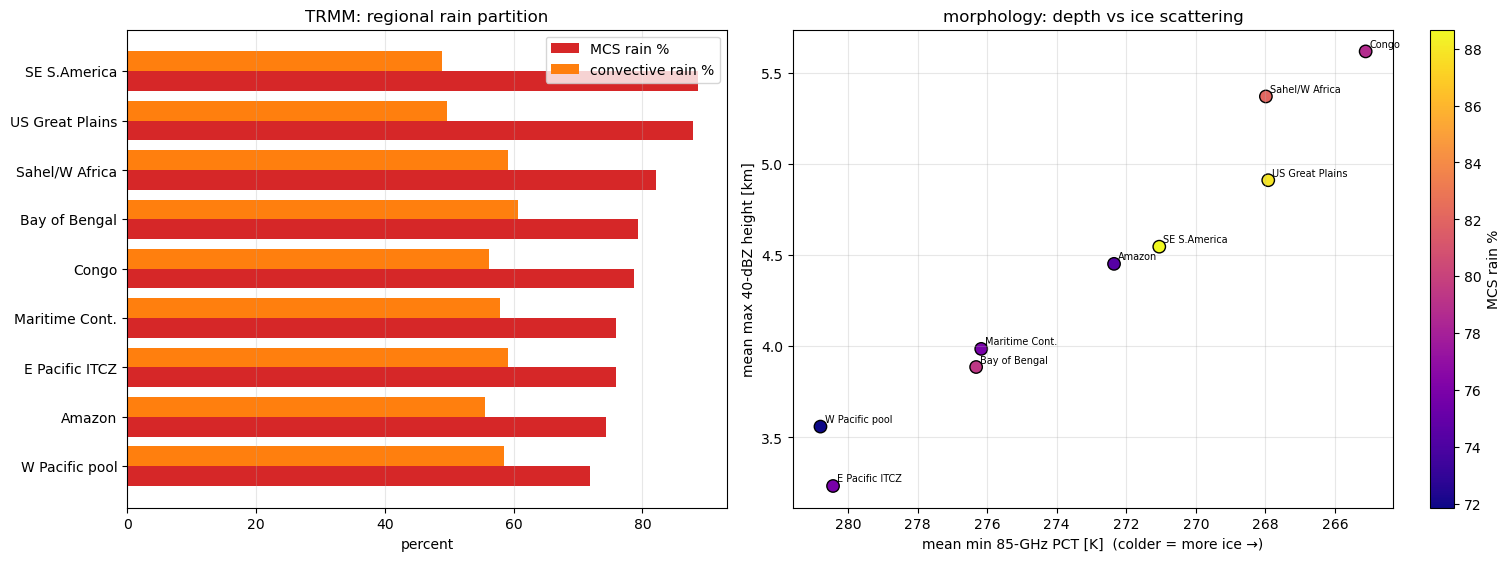

In [9]:
REGIONS = {
 "Amazon":            (-15,   5,  -75, -50), "Congo":           (-10,  10,   10,  35),
 "Maritime Cont.":    (-10,  10,   95, 150), "W Pacific pool":  (  0,  15,  130, 170),
 "E Pacific ITCZ":    (  2,  12, -140, -90), "Sahel/W Africa":  (  5,  18,  -15,  30),
 "US Great Plains":   ( 30,  48, -105, -85), "SE S.America":    (-38, -20,  -65, -45),
 "Bay of Bengal":     (  5,  22,   80, 100),
}
rows = []
for name, (la0, la1, lo0, lo1) in REGIONS.items():
    r = q("""
        SELECT 100.0*sum(volrain_total) FILTER(WHERE feature_class='MCS')/sum(volrain_total) AS mcs_rain_pct,
               100.0*sum(volrain_conv)/sum(volrain_total) AS conv_pct,
               avg(max_ht_40dbz)/1000.0 AS mean_ht_km, avg(min_pct_85_89) AS mean_min_pct,
               count(*) AS n
        FROM features WHERE mission=? AND centroid_lat BETWEEN ? AND ? AND centroid_lon BETWEEN ? AND ?
    """, la0, la1, lo0, lo1).iloc[0]
    rows.append(dict(region=name, **r.to_dict()))
reg = pd.DataFrame(rows).set_index("region")
print(f"{MISSION} — regional morphology:\n")
print(reg.assign(n=reg.n.map("{:,.0f}".format)).round(1).to_string())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
o = reg.sort_values("mcs_rain_pct")
y = np.arange(len(o)); w = 0.4
a1.barh(y - w/2, o.mcs_rain_pct, w, color="tab:red", label="MCS rain %")
a1.barh(y + w/2, o.conv_pct, w, color="tab:orange", label="convective rain %")
a1.set_yticks(y); a1.set_yticklabels(o.index); a1.set_xlabel("percent")
a1.set_title(f"{MISSION}: regional rain partition"); a1.legend(); a1.grid(axis="x", alpha=0.3)
sc = a2.scatter(reg.mean_min_pct, reg.mean_ht_km, c=reg.mcs_rain_pct, cmap="plasma",
                s=80, edgecolor="k")
for nm, r in reg.iterrows():
    a2.annotate(nm, (r.mean_min_pct, r.mean_ht_km), fontsize=7, xytext=(3, 3), textcoords="offset points")
a2.set_xlabel("mean min 85-GHz PCT [K]  (colder = more ice →)"); a2.invert_xaxis()
a2.set_ylabel("mean max 40-dBZ height [km]")
a2.set_title("morphology: depth vs ice scattering"); fig.colorbar(sc, ax=a2, label="MCS rain %")
a2.grid(alpha=0.3)
plt.show()